In [13]:
# read before implementing: http://scikit-survival.readthedocs.io/en/stable/user_guide/coxnet.html

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import FitFailedWarning

from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.util import Surv

# Preparing Data

In [14]:
# load in datasets
df = pd.read_csv('../datasets/csv_files/univariate_cox_sig_train.csv')
expr = pd.read_csv('../datasets/csv_files/filtered_expression_matrix_train.csv')
clinical = pd.read_csv('../datasets/csv_files/clinical_metadata_train.csv')
clinical.head()

,sample_name,sample_id,tissue_type,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time,overall_survival_event,overall_survival_time
0,GSM1045191,GSM1045191,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GSM1045192,GSM1045192,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GSM1045193,GSM1045193,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GSM1045194,GSM1045194,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GSM1045195,GSM1045195,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# make a list of all sig genes
sig_genes = list(df['gene'])

def filter_expr_matrix(sig_genes):
    columns_to_keep = ['sample_name'] + sig_genes
    expr_filtered = expr[columns_to_keep]
    return expr_filtered

expr_filtered = filter_expr_matrix(sig_genes)
clinical.head()

,sample_name,sample_id,tissue_type,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time,overall_survival_event,overall_survival_time
0,GSM1045191,GSM1045191,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GSM1045192,GSM1045192,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GSM1045193,GSM1045193,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GSM1045194,GSM1045194,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GSM1045195,GSM1045195,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# prepare train data
clinical_columns = ['sample_name', 'relapse_free_event', 'relapse_free_time']

train_data = pd.merge(
    clinical[clinical_columns],
    expr_filtered[:],
    on='sample_name'
)

train_data = train_data.dropna()
train_data[['relapse_free_event', 'relapse_free_time']] = train_data[['relapse_free_event', 'relapse_free_time']].astype(int)

train_data.head()

,sample_name,relapse_free_event,relapse_free_time,FBXL5,EVL,POLR3GL,CDC20,KLHL5,GATA3,BLNK,...,TF,DCTN6,MYB,ALDOC,PRLR,S100B,CXCL12,FOS,CLU,DENND1B
17,GSM1045208,0,3026,7.780658,9.176116,7.009545,6.583813,4.727495,11.243921,8.036585,...,4.314603,5.922452,5.503582,5.383726,5.409960,2.802160,7.329267,4.866050,6.878972,5.150305
18,GSM1045209,1,755,7.242231,7.921031,6.696948,8.425245,4.202276,10.374649,6.248417,...,4.921310,6.672498,5.670921,5.854996,5.118496,3.144127,7.558426,6.014123,7.780951,5.222316
19,GSM1045210,0,3014,7.540444,8.894975,6.311942,7.338158,4.771116,10.954085,7.606303,...,4.437907,5.868416,5.181722,5.317867,5.396281,2.819787,7.058830,3.910671,7.028702,4.926403
20,GSM1045211,1,406,6.171535,8.815157,6.221754,7.468727,3.711394,9.546771,5.238047,...,4.252302,5.885133,4.632032,6.408760,4.227421,3.107371,7.541663,6.202788,5.895270,4.022105
21,GSM1045212,0,2225,7.167023,6.811868,7.567759,9.645149,4.633546,8.410182,6.438748,...,4.873803,5.957434,3.345111,8.048325,4.102159,3.240011,7.788142,8.218544,6.810512,4.499718


In [17]:
# prepare x & y
x = train_data.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
y = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', train_data)

In [18]:
def plot_coefficients(coefs, n_highlight):
    fig, ax = plt.subplots(figsize=(9, 6))
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(alpha_min, coef, name + "   ", horizontalalignment="right", verticalalignment="center")

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

# LASSO

In [19]:
def lasso_cox(x, y):
    cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
    cox_lasso.fit(x, y)

    return pd.DataFrame(cox_lasso.coef_, index=x.columns, columns=np.round(cox_lasso.alphas_, 5))

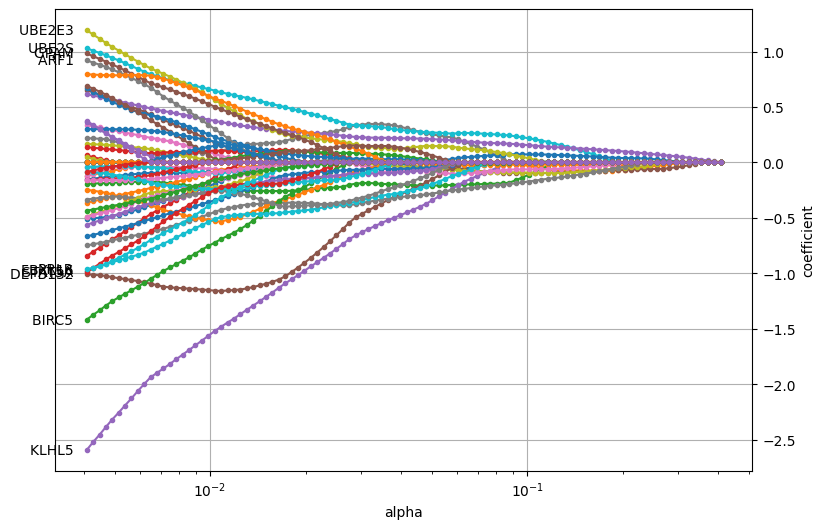

In [20]:
coeff_lasso = lasso_cox(x, y)
plot_coefficients(coeff_lasso, 10)

# Elastic Net

In [21]:
def elastic_net_cox(x, y):
    cox_elastic_net = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01)
    cox_elastic_net.fit(x, y)

    return pd.DataFrame(
        cox_elastic_net.coef_, index=x.columns, columns=np.round(cox_elastic_net.alphas_, 5)
    )

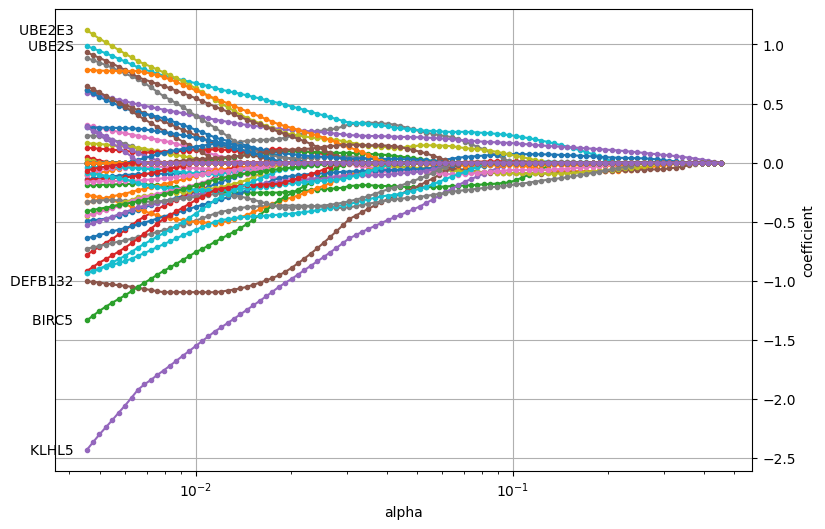

In [22]:
coeff_elastic_net = elastic_net_cox(x, y)
plot_coefficients(coeff_elastic_net, 5)

# Choose Alpha Strength

In [23]:
def get_alpha_max_min(x, y, l1_ratio=1.0):
    coxnet_pipe = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=l1_ratio, alpha_min_ratio=0.01, max_iter=100))
    warnings.simplefilter("ignore", UserWarning)
    warnings.simplefilter("ignore", FitFailedWarning)
    coxnet_pipe.fit(x, y)
    estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
    return coxnet_pipe, estimated_alphas

In [24]:
def cross_validate(x, y, coxnet_pipe, estimated_alphas, l1_ratio=1.0):
    estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
    cv = KFold(n_splits=5, shuffle=True, random_state=0)
    gcv = GridSearchCV(
        make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=l1_ratio)),
        param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, estimated_alphas)]},
        cv=cv,
        error_score=0.5,
        n_jobs=1,
    ).fit(x, y)
    cv_results = pd.DataFrame(gcv.cv_results_)
    return cv_results, gcv

In [25]:
def plot_alphas(cv_results, gcv):
    alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
    mean = cv_results.mean_test_score
    std = cv_results.std_test_score

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(alphas, mean)
    ax.fill_between(alphas, mean - std, mean + std, alpha=0.15)
    ax.set_xscale("log")
    ax.set_ylabel("concordance index")
    ax.set_xlabel("alpha")
    ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
    ax.axhline(0.5, color="grey", linestyle="--")
    ax.grid(True)

In [26]:
def find_sig_genes(x, y, gcv):
    best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
    best_coefs = pd.DataFrame(best_model.coef_, index=x.columns, columns=["coefficient"])

    non_zero_coefs = best_coefs.query("coefficient != 0")
    coef_order = non_zero_coefs.abs().sort_values("coefficient").index

    new_sig_genes = [name for name in non_zero_coefs.index]
    c_index = gcv.best_score_
    print(f"Number of non-zero coefficients: {len(new_sig_genes)}")
    print(f"Best CV Concordance Index: {c_index}")

    _, ax = plt.subplots(figsize=(6, 8))
    non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
    ax.set_xlabel("coefficient")
    ax.grid(True)
    return new_sig_genes, c_index

In [27]:
def check_paper_genes(gene_list):
    signature_genes = ["TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1"]

    found = [g for g in signature_genes if g in gene_list]
    missing = [g for g in signature_genes if g not in gene_list]

    print(f"Found ({len(found)}): {found}")
    print(f"Missing ({len(missing)}): {missing}")

# LASSO Alpha Strength

In [28]:
coxnet_pipe, estimated_alphas = get_alpha_max_min(x, y)
cv_results, gcv = cross_validate(x, y, coxnet_pipe, estimated_alphas)

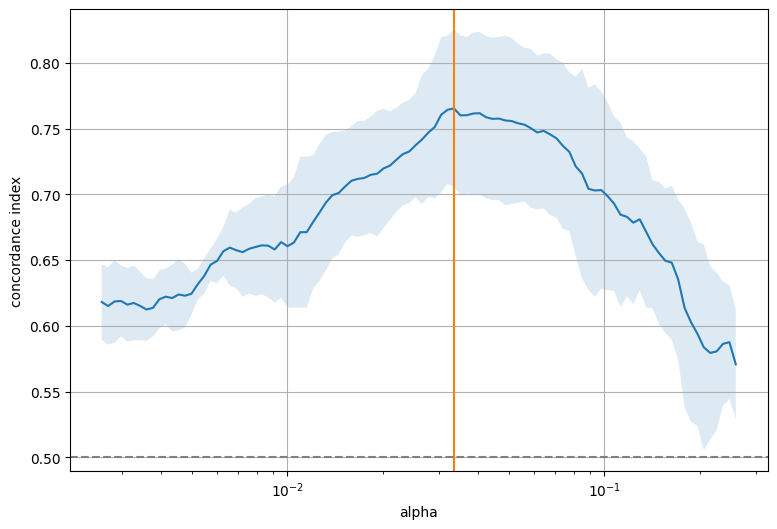

In [29]:
plot_alphas(cv_results, gcv)

Number of non-zero coefficients: 21
Best CV Concordance Index: 0.7653116442335357


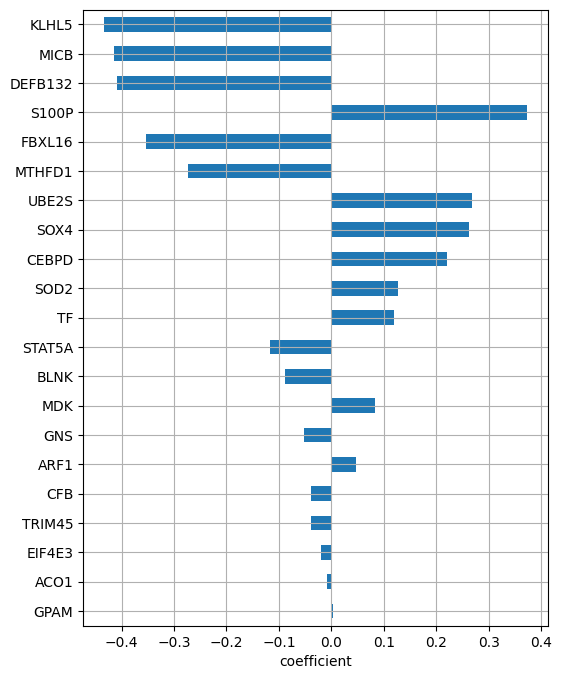

In [30]:
lasso_sig_genes, lasso_c_index = find_sig_genes(x, y, gcv)

In [31]:
check_paper_genes(lasso_sig_genes)

Found (4): ['MDK', 'S100P', 'BLNK', 'ACO1']
Missing (4): ['TSLP', 'BIRC5', 'S100B', 'RARRES3']


# Elastic Net Alpha Strength

In [32]:
coxnet_pipe, estimated_alphas = get_alpha_max_min(x, y, 0.9)
cv_results, gcv = cross_validate(x, y, coxnet_pipe, estimated_alphas, 0.9)

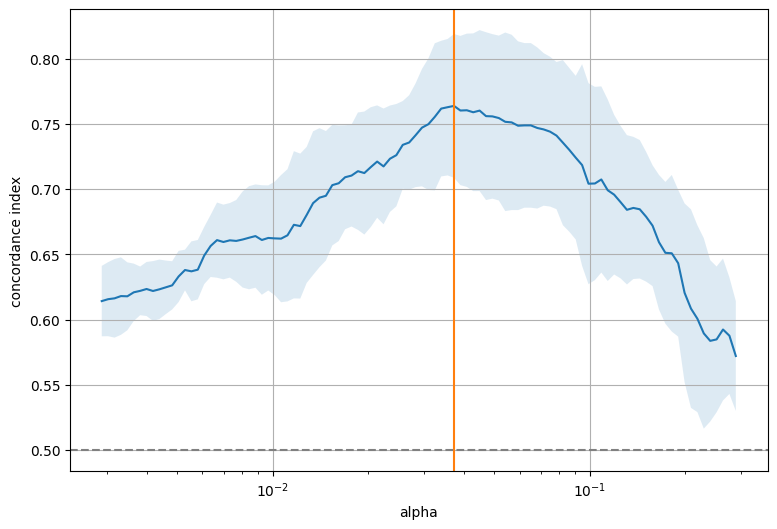

In [33]:
plot_alphas(cv_results, gcv)

Number of non-zero coefficients: 21
Best CV Concordance Index: 0.763752469873046


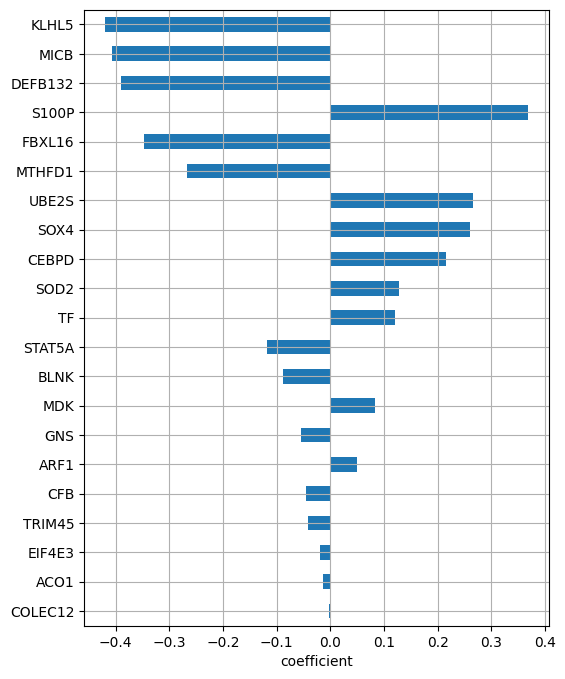

In [34]:
elastic_net_sig_genes, elastic_net_c_index = find_sig_genes(x, y, gcv)

In [35]:
best_model = elastic_net_sig_genes
check_paper_genes(best_model)

Found (4): ['MDK', 'S100P', 'BLNK', 'ACO1']
Missing (4): ['TSLP', 'BIRC5', 'S100B', 'RARRES3']


In [36]:
penalized_cox_expr = filter_expr_matrix(best_model)
penalized_cox_expr.head()

,sample_name,KLHL5,BLNK,SOX4,UBE2S,S100P,DEFB132,COLEC12,MICB,EIF4E3,...,FBXL16,CFB,SOD2,TRIM45,MTHFD1,MDK,CEBPD,STAT5A,ACO1,TF
0,GSM1045191,6.072575,5.236619,6.020647,4.445544,5.073908,8.357489,7.386655,5.413113,6.647043,...,4.139581,5.875372,9.288465,4.930487,9.063218,5.188450,8.235638,7.981321,6.697765,6.901910
1,GSM1045192,4.181562,5.595045,6.048561,4.422642,4.521399,3.296474,6.404261,6.659727,4.446082,...,4.614759,5.743448,8.606902,4.745991,6.632947,6.270123,6.229825,7.601242,5.872591,4.818204
2,GSM1045193,5.337126,8.674915,4.799969,4.878597,4.638771,2.953570,4.816429,6.921534,4.109932,...,4.833464,5.258735,4.838683,5.288228,5.941661,5.771265,4.134739,7.501134,4.704279,4.746406
3,GSM1045194,4.675391,4.519967,7.113616,4.498002,5.977879,3.292748,4.931116,5.217874,4.598521,...,4.935647,5.351327,9.178988,5.912944,6.383969,6.423919,7.220704,7.285756,4.650540,4.738504
4,GSM1045195,6.000885,4.955369,5.754098,4.847608,4.839788,6.843711,8.182421,5.132874,6.837103,...,3.937953,5.574557,10.132265,4.677008,9.651571,5.001135,7.528966,8.350870,8.647494,7.463235


In [37]:
# ============================================================================
# Save results to CSV
# ============================================================================
penalized_cox_expr.to_csv("../datasets/csv_files/penalized_cox_sig_genes_train.csv", index=False)